In [33]:
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from skimage import img_as_float



data = scipy.io.loadmat('facedata.mat')
print("Person index:", data['facedata'].shape[0])
print("Pose index:", data['facedata'].shape[1])

Person index: 40
Pose index: 10


[[48 46 50 ... 50 54 53]
 [47 47 48 ... 37 46 50]
 [46 48 43 ... 33 41 51]
 ...
 [49 49 50 ... 45 46 47]
 [48 48 49 ... 45 46 46]
 [51 48 50 ... 45 45 46]]
(56, 46)


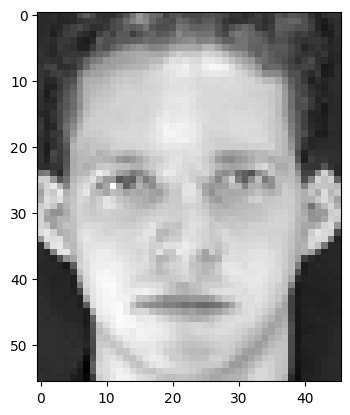

In [34]:
print(data['facedata'][0][0])
print(data['facedata'][0][0].shape)
plt.imshow(data['facedata'][0][0], cmap='gray')
plt.show()

In [35]:
xf = {}
xf[0,0] = img_as_float(data['facedata'][0][0])
print(xf[0,0])

[[0.18823529 0.18039216 0.19607843 ... 0.19607843 0.21176471 0.20784314]
 [0.18431373 0.18431373 0.18823529 ... 0.14509804 0.18039216 0.19607843]
 [0.18039216 0.18823529 0.16862745 ... 0.12941176 0.16078431 0.2       ]
 ...
 [0.19215686 0.19215686 0.19607843 ... 0.17647059 0.18039216 0.18431373]
 [0.18823529 0.18823529 0.19215686 ... 0.17647059 0.18039216 0.18039216]
 [0.2        0.18823529 0.19607843 ... 0.17647059 0.17647059 0.18039216]]


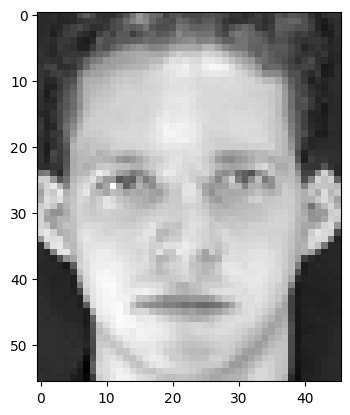

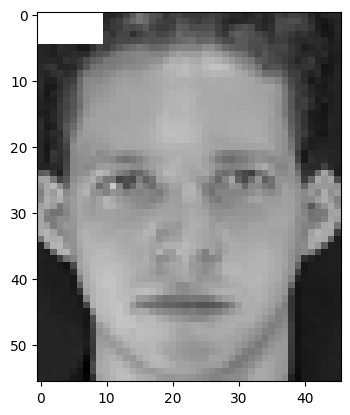

In [36]:
plt.imshow(xf[0,0], cmap='gray')
plt.show()
x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1
plt.imshow(x_temp, cmap='gray')
plt.show()

### Part 1

In [37]:
#Euclidean_dis

xf = {}
xf[0,0] = img_as_float(data['facedata'][0][0])
xf[0,1] = img_as_float(data['facedata'][0][1])
xf[1,0] = img_as_float(data['facedata'][1][0])

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

print(euclidean_distance(xf[0,0], xf[0,1]))
print(euclidean_distance(xf[0,0], xf[1,0]))

10.037616294165492
8.173295099737281


In [38]:
print("Person index:", data['facedata'].shape[0])
print("Pose index:", data['facedata'].shape[1])

Person index: 40
Pose index: 10


In [39]:
#split data into training and test sets
T = {} # training set
D = {} # test set
for i in range(data['facedata'].shape[0]):
    for j in range(data['facedata'].shape[1]):
        if j < 3:
            T[i,j] = img_as_float(data['facedata'][i][j])
        else:
            D[i,j] = img_as_float(data['facedata'][i][j])

print("Training set size:", len(T))
print("Test set size:", len(D))

Training set size: 120
Test set size: 280


In [40]:
# Create a similarity matrix A where A[i,j] is the Euclidean distance between xf[i] and xf[j]
# def compute_similarity_matrix(T,D):
#     A = np.zeros((3 * 40, 7 * 40))
#     for i in range(40):
#         for k in range(3):
#             for j in range(40):
#                 for l in range(7):
#                     A[k * 40 + i, l * 40 + j] = euclidean_distance(T[i,k], D[j,3+l])
#     return A
# A = compute_similarity_matrix(T,D)

def compute_similarity_matrix(T,D):
    A = np.zeros((120,40,7))
    for fig , train_dict in enumerate(T):
        for i in range(40):
            for k in range(7):
                A[fig,i,k] = euclidean_distance(T[train_dict], D[i,3+k])
    return A
A = compute_similarity_matrix(T,D)
print(A.shape)

(120, 40, 7)


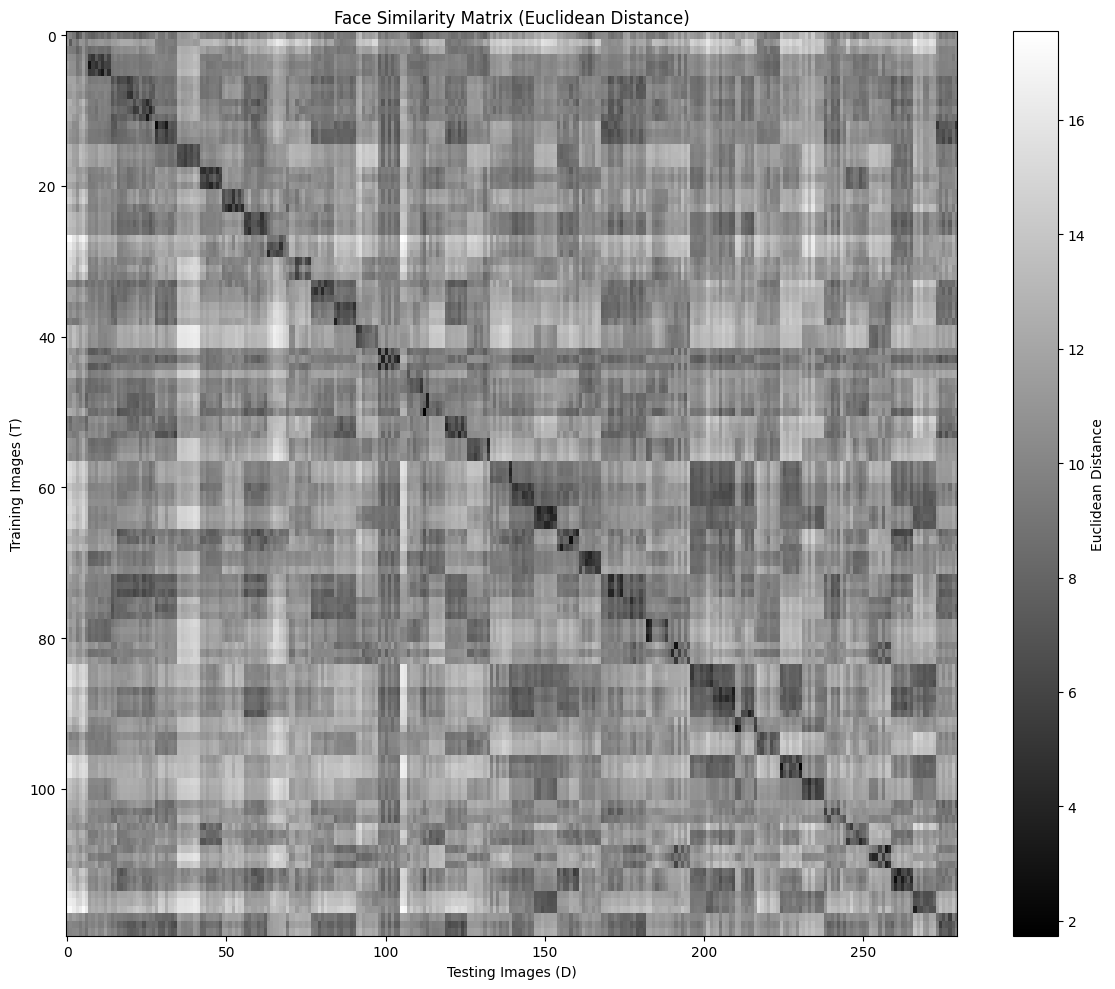

In [41]:
plt.figure(figsize=(12, 10))
plt.imshow(A.reshape(120,280), cmap='gray', aspect='auto')
plt.colorbar(label='Euclidean Distance')
plt.xlabel('Testing Images (D)')
plt.ylabel('Training Images (T)')
plt.title('Face Similarity Matrix (Euclidean Distance)')
plt.tight_layout()
plt.show()

In [42]:
# Is similar face reture ture positive and false alarm


def is_similar_face(A, threshold):
    sameface = {}
    true_positives_rate = 0
    true_negatives_rate = 0
    false_negatives_rate = 0
    false_positives_rate = 0
    for l in range(A.shape[3]):
        for i in range(40):
            for j in range(40):
                t = 0
                f = 0
                for k in range(A.shape[1]):
                    if A[i,k,j,l] < threshold:
                        if j == i:
                            t = 1
                        else:
                            t = 2
                    else:
                        if j == i:
                            f = 1
                if t == 1:
                    true_positives_rate += 1
                elif t == 2:
                    false_positives_rate += 1
                elif f == 1:
                    false_negatives_rate += 1
                else:
                    true_negatives_rate += 1
                    
                        
    return true_positives_rate,true_negatives_rate, false_negatives_rate, false_positives_rate                
                        
true_positives_rate, true_negatives_rate, false_negatives_rate, false_positives_rate = is_similar_face(A.reshape(40,3,40,7), 10)
print("True positives rate:", true_positives_rate)
print("True negatives rate:", true_negatives_rate)
print("False negatives rate:", false_negatives_rate)
print("False positives rate:", false_positives_rate)


True positives rate: 279
True negatives rate: 5936
False negatives rate: 1
False positives rate: 4984


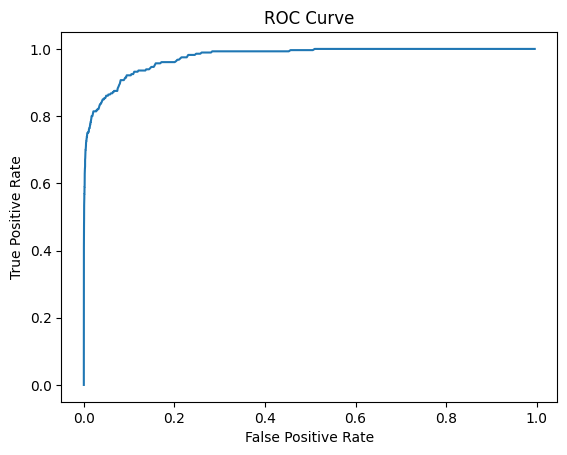

In [43]:
# Plot the ROC curve
num_thresholds = 1000
thresholds = np.linspace(0, 15, num_thresholds)
tpr = []
fpr = []
for threshold in thresholds:
    true_positives_rate, true_negatives_rate, false_negatives_rate, false_positives_rate = is_similar_face(A.reshape(40,3,40,7), threshold)
    tpr.append(true_positives_rate / (true_positives_rate + false_negatives_rate))
    fpr.append(false_positives_rate / (false_positives_rate + true_negatives_rate))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

#### Part 5

In [44]:
# PCA
# Compute the mean vector from the training set
F = 56 * 46
mean_vector = np.zeros((1, F))
for i in range(40):
    for k in range(3):
        mean_vector += T[i,k].flatten()
mean_vector /= (40 * 3)
print(mean_vector.shape)



(1, 2576)


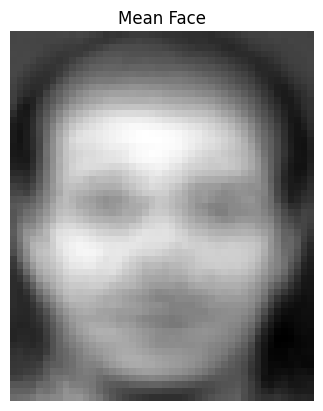

In [45]:
# Plot the mean face
mean_face = mean_vector.reshape(56, 46)
plt.imshow(mean_face, cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show()

In [46]:
# Compute eigenvectors and eigenvalues of the covariance matrix
def compute_covariance_matrix(T, mean_vector):
    C = np.zeros((F, F))
    for i in range(40):
        for k in range(3):
            x = T[i,k].flatten() - mean_vector.flatten()
            C += np.outer(x, x)
    C /= (40 * 3)
    return C
C = compute_covariance_matrix(T, mean_vector)
eigenvalues, eigenvectors = np.linalg.eig(C)
print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (2576,)
Eigenvectors shape: (2576, 2576)


In [47]:
print("Covariance matrix shape:",C.shape)

Covariance matrix shape: (2576, 2576)


In [48]:
# Find Rank of the covariance matrix
rank = np.linalg.matrix_rank(C)
print("Rank of the covariance matrix:", rank)

Rank of the covariance matrix: 119


### part 7

In [49]:
# compute the GRAM matrix
X = np.zeros((40 * 3, F))
for i in range(40):
    for k in range(3):
        X[i*3+k] = T[i,k].flatten() - mean_vector.flatten()
G = X @ X.T
print("GRAM matrix shape:", G.shape)
rank_G = np.linalg.matrix_rank(G)
print("Rank of the GRAM matrix:", rank_G)


GRAM matrix shape: (120, 120)
Rank of the GRAM matrix: 119


In [50]:
# Is Gram matrix are symmetric
is_symmetric = np.allclose(G, G.T)
print("Is the GRAM matrix symmetric?", is_symmetric)

Is the GRAM matrix symmetric? True


In [51]:
# Compute the eigenvectors and eigenvalues of the covariance matrix using the GRAM matrix
eigenvalues_gram, eigenvectors_gram = np.linalg.eig(G)

In [52]:
# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues_gram)[::-1]
eigenvalues_gram = eigenvalues_gram[sorted_indices]
eigenvectors_gram = eigenvectors_gram[:, sorted_indices]

print("Eigenvectors from GRAM matrix:", eigenvectors_gram)

Eigenvectors from GRAM matrix: [[ 0.07820028 -0.08144841  0.16838572 ... -0.03284951 -0.01171851
   0.09128709]
 [ 0.15633363 -0.06891888  0.00607299 ... -0.00712131 -0.00347436
   0.09128709]
 [ 0.14076739 -0.04460943  0.08922514 ...  0.03802993 -0.01301747
   0.09128709]
 ...
 [ 0.03542524 -0.08254825 -0.13635891 ... -0.01356318 -0.00197116
   0.09128709]
 [ 0.04815903 -0.11167625 -0.06627051 ... -0.03108812  0.02639082
   0.09128709]
 [ 0.04395375 -0.12893456 -0.07990511 ...  0.02085834 -0.01616482
   0.09128709]]


In [53]:
# Count Non-zero eigenvalues If see a very small value, it is just numerical error and should be treated as zero
non_zero_eigenvalues = np.sum(eigenvalues_gram > 1e-10)
print("Number of non-zero eigenvalues:", non_zero_eigenvalues)

Number of non-zero eigenvalues: 119


Text(0.5, 0, 'Index')

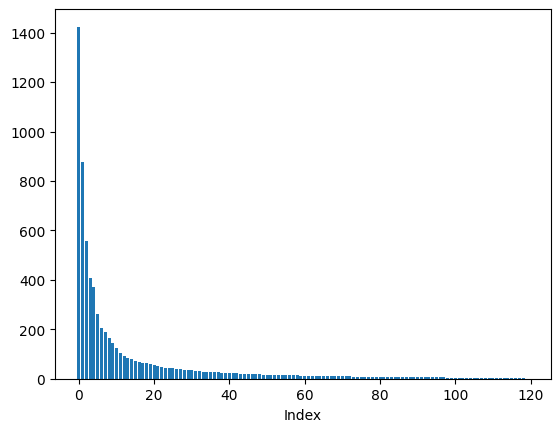

In [54]:
# Plot the eigenvalues in bar graph
plt.bar(range(len(eigenvalues_gram)), eigenvalues_gram)
plt.xlabel('Index')

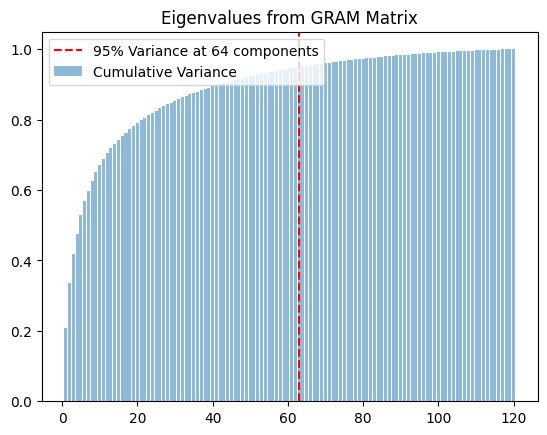

In [55]:
# Keep the 95% of the variance
total_variance = np.sum(eigenvalues_gram)
target_variance = 0.95 * total_variance
cumulative_variance = np.cumsum(eigenvalues_gram)
num_components = np.searchsorted(cumulative_variance, target_variance) + 1

plt.title('Eigenvalues from GRAM Matrix')
plt.bar(range(1, len(cumulative_variance)+1), cumulative_variance / total_variance, alpha=0.5, label='Cumulative Variance')
plt.axvline(x=num_components-1, color='r', linestyle='--', label=f'95% Variance at {num_components} components')
plt.legend()


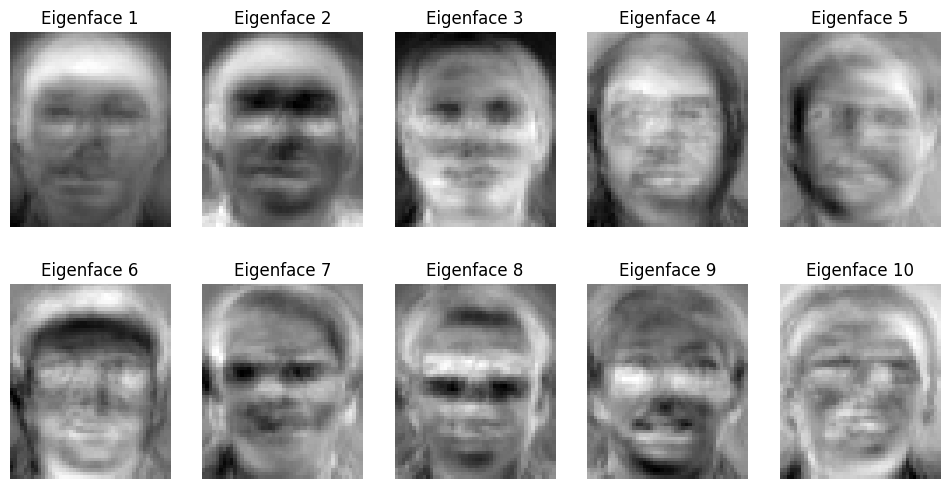

In [56]:
# Show the first 10 eigenvector as images
plt.figure(figsize=(12, 6))
for i in range(10):
    eigenface = X.T @ eigenvectors_gram[:, i]
    plt.subplot(2, 5, i+1)
    plt.imshow(eigenface.reshape(56, 46), cmap='gray')
    plt.title(f'Eigenface {i+1}')
    plt.axis('off')

In [57]:
# Project training images onto the first k=10 principal components
k = 10
eigenfaces = X.T @ eigenvectors_gram[:, :k]
# projected_images = X @ eigenfaces
projected_images = eigenfaces/np.linalg.norm(eigenfaces, axis=0)

In [58]:
train_proj = np.zeros((40, 3, 10))
test_proj = np.zeros((40, 7, 10))
mean_face = mean_vector.flatten()

for i in range(40):
    for j in range(3):
        x = T[i, j].reshape(-1)
        train_proj[i, j] = projected_images.T @ (x - mean_face)

for i in range(40):
    for j in range(7):
        x = D[i, j+3].reshape(-1)
        test_proj[i, j] = projected_images.T @ (x - mean_face)

In [59]:
A13 = np.zeros((120,40,7)) # [test figure, train person, train pose]
# compute the similarity matrix A13 using the projected training and test images
for num_fig,train_dict in enumerate(T):
    for check_people in range(40):
        for check_pose in range(7):
            A13[num_fig, check_people, check_pose] = euclidean_distance(train_proj[train_dict], test_proj[check_people,check_pose])
                
true_positives_rate, true_negatives_rate, false_negatives_rate, false_positives_rate = is_similar_face(A13.reshape(40,3,40,7), 10)

In [60]:
print("True positives rate:", true_positives_rate)
print("True negatives rate:", true_negatives_rate)
print("False negatives rate:", false_negatives_rate)
print("False positives rate:", false_positives_rate)

True positives rate: 280
True negatives rate: 1710
False negatives rate: 0
False positives rate: 9210


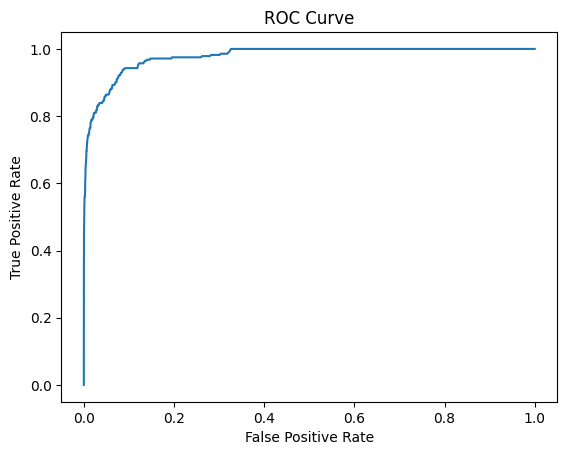

In [61]:
# Plot the ROC curve
num_thresholds = 1000
thresholds = np.linspace(0, 15, num_thresholds)
tpr = []
fpr = []
for threshold in thresholds:
    true_positives_rate, true_negatives_rate, false_negatives_rate, false_positives_rate = is_similar_face(A13.reshape(40,3,40,7), threshold)
    tpr.append(true_positives_rate / (true_positives_rate + false_negatives_rate))
    fpr.append(false_positives_rate / (false_positives_rate + true_negatives_rate))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [66]:
thresholds = np.asarray(thresholds)
tpr = np.array(tpr)
fpr = np.array(fpr)

False Alarm Rate = 0.07875457875457875
True Positive Rate = 0.9214285714285714
Threshold = 4.78978978978979


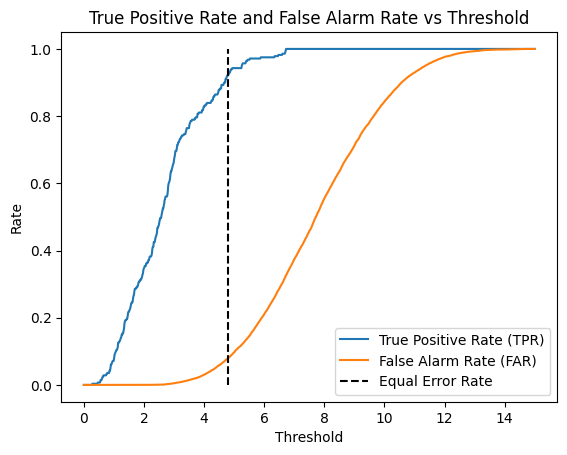

In [70]:
dist_to_line = np.abs(tpr - (1 - fpr)) / np.sqrt(2)
idx = np.argmin(dist_to_line)

plt.plot(thresholds, tpr, label='True Positive Rate (TPR)')
plt.plot(thresholds, fpr, label='False Alarm Rate (FAR)')
plt.plot([thresholds[idx], thresholds[idx]], [0, 1], 'k--', label='Equal Error Rate')
plt.title('True Positive Rate and False Alarm Rate vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()

print("False Alarm Rate =", fpr[idx])
print("True Positive Rate =", tpr[idx])
print("Threshold =", thresholds[idx])

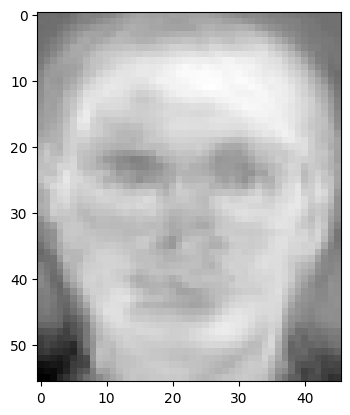

In [ ]:
# Reconstruct the first images using the first k=10 principal components
reconstructed_image = projected_images[0] @ eigenfaces.T + mean_vector.flatten()
plt.imshow(reconstructed_image.reshape(56, 46), cmap='gray')